# Model
### Binary Classification
### No class no-snore

In [1]:
import os, random, json, math
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    get_linear_schedule_with_warmup
)

d:\V89\gus\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
# Configuration
TRAIN_NPY_DIR = Path(r"D:\V89\data2\train_npy")
TEST_NPY_DIR  = Path(r"D:\V89\data_test\test_npy")

TRAIN_CSV = r"D:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_train\train\use_train_osa.csv"
TEST_CSV  = r"D:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test_osa.csv"

SAVE_DIR  = Path(r"D:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V5")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16000
SEGMENT_SECONDS = 5.0
SEG_SAMPLES = int(TARGET_SR * SEGMENT_SECONDS)
BATCH_SIZE = 4
EPOCHS = 25
LR = 1e-5
VAL_THRESHOLD = 0.50
PROCESSOR_NAME = "facebook/wav2vec2-base-960h"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name())

Device: cuda
GPU: NVIDIA GeForce RTX 4060


In [36]:
# Binary classification mapping - Back to OSA vs Snore only
def map_type_to_label(t: str) -> int:
    """
    Map type to binary classes:
    0 = Snore
    1 = ObstructiveApnea (OSA)
    
    Note: Filtering out no_Snore samples
    """
    if t == "ObstructiveApnea":
        return 1
    elif t == "Snore":
        return 0
    else:
        # Return None for classes we want to filter out (like no_Snore)
        return None

In [37]:
# Load processor
processor = Wav2Vec2Processor.from_pretrained(PROCESSOR_NAME)

# Data loading and preprocessing
df_train_all = pd.read_csv(TRAIN_CSV)
df_test_all  = pd.read_csv(TEST_CSV)

# Apply mapping and filter out None values (no_Snore samples)
df_train_all["label"] = df_train_all["type"].map(map_type_to_label)
df_test_all["label"]  = df_test_all["type"].map(map_type_to_label)

# Filter out samples with None labels (no_Snore)
df_train_all = df_train_all.dropna(subset=['label']).reset_index(drop=True)
df_test_all = df_test_all.dropna(subset=['label']).reset_index(drop=True)

# Convert to int after filtering
df_train_all["label"] = df_train_all["label"].astype(int)
df_test_all["label"] = df_test_all["label"].astype(int)

# Check class distribution
print("Training data class distribution:")
print("0 (Snore):", (df_train_all["label"] == 0).sum())
print("1 (OSA):", (df_train_all["label"] == 1).sum())
print("\nTest data class distribution:")
print("0 (Snore):", (df_test_all["label"] == 0).sum())
print("1 (OSA):", (df_test_all["label"] == 1).sum())

Training data class distribution:
0 (Snore): 1394
1 (OSA): 1766

Test data class distribution:
0 (Snore): 415
1 (OSA): 447


In [38]:
train_df, val_df = train_test_split(
    df_train_all, test_size=0.2, stratify=df_train_all["label"], random_state=SEED
)
print(f"\nTrain size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(df_test_all)}")


Train size: 2528, Val size: 632, Test size: 862


In [39]:
def resolve_npy_path(root_dir: Path, pid: int, seg_index: int) -> Path | None:
    """
    patient_id + segment_index -> find Mic .npy file
    """
    pid_str = f"{int(pid):08d}"
    seg_str = f"[{int(seg_index)+1:03d}]"

    # common patterns
    candidates = [
        f"{pid_str}-100507{seg_str}_mic.npy",
        f"{pid_str}{seg_str}_mic.npy",
    ]

    for fname in candidates:
        path = root_dir / fname
        if path.exists():
            return path

    # fallback: search for files with pid + seg + _mic.npy
    hits = list(root_dir.rglob(f"*{pid_str}*{seg_str}*_mic.npy"))
    return hits[0] if hits else None

def load_mic_from_npy(npy_path: Path) -> np.ndarray | None:
    try:
        arr = np.load(npy_path).astype(np.float32)
        if arr.ndim > 1:
            arr = arr.reshape(-1)
        return arr
    except Exception as e:
        print(f"[load_mic_from_npy] error {npy_path}: {e}")
        return None

def slice_segment(wave: np.ndarray, start_sec: float, dur_sec: float,
                  sr: int = TARGET_SR, fixed_len: int = SEG_SAMPLES) -> np.ndarray | None:
    if wave is None or len(wave) == 0:
        return None
    start = int(max(0.0, float(start_sec)) * sr)
    end = start + int(float(dur_sec) * sr)
    if start >= len(wave):
        return None
    seg = wave[start:min(end, len(wave))]
    if len(seg) <= 0:
        return None
    if len(seg) < fixed_len:
        seg = np.pad(seg, (0, fixed_len - len(seg)), mode="constant")
    else:
        seg = seg[:fixed_len]
    return seg.astype(np.float32)

def collate_w2v2(batch):
    """Collate function for Wav2Vec2"""
    input_values = []
    labels = []
    
    for item in batch:
        if len(item) == 2:
            audio, label = item
            input_values.append(audio)
            labels.append(label)
    
    if not input_values:
        return {
            "input_values": torch.zeros((1, SEG_SAMPLES)),
            "attention_mask": None,
            "labels": torch.tensor([0])
        }
    
    # Process audio with Wav2Vec2Processor
    processed = processor(
        [x.numpy() for x in input_values],  # ensure it's a list of 1D numpy arrays
        sampling_rate=TARGET_SR, 
        return_tensors="pt", 
        padding=True
    )
    
    return {
        "input_values": processed.input_values,
        "attention_mask": processed.get("attention_mask", None),
        "labels": torch.stack(labels)
    }

In [40]:
class W2V2NpyDataset(Dataset):
    def __init__(self, df: pd.DataFrame, npy_root: Path, target_sr=TARGET_SR, seg_seconds=SEGMENT_SECONDS):
        self.df = df.reset_index(drop=True)
        self.root = npy_root
        self.target_sr = target_sr
        self.seg_seconds = seg_seconds

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            r = self.df.iloc[idx]
            pid = int(r["patient_id"])
            seg_index = int(r["segment_index"])
            start_sec = float(r.get("segment_local_start_sec", r.get("start_sec", 0.0)))
            dur_sec   = min(float(r.get("duration_sec", self.seg_seconds)), self.seg_seconds)

            p = resolve_npy_path(self.root, pid, seg_index)
            if p is None or not p.exists():
                raise FileNotFoundError(f"No file for pid={pid} seg={seg_index}")

            wave = load_mic_from_npy(p)
            seg  = slice_segment(wave, start_sec, dur_sec, sr=self.target_sr, fixed_len=SEG_SAMPLES)
            if seg is None:
                seg = slice_segment(wave, 0.0, self.seg_seconds, sr=self.target_sr, fixed_len=SEG_SAMPLES)
                if seg is None:
                    raise RuntimeError(f"Empty segment for {p}")

            y = int(r["label"])
            return torch.tensor(seg), torch.tensor(y, dtype=torch.long)

        except Exception as e:
            print(f"[Dataset] Skipping index {idx} due to error: {e}")
            return torch.zeros(SEG_SAMPLES, dtype=torch.float32), torch.tensor(0)


In [41]:
# Create datasets and dataloaders
train_ds = W2V2NpyDataset(train_df, TRAIN_NPY_DIR)
val_ds   = W2V2NpyDataset(val_df,   TRAIN_NPY_DIR)
test_ds  = W2V2NpyDataset(df_test_all, TEST_NPY_DIR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)

In [42]:
# Initialize model for binary classification
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    PROCESSOR_NAME,
    num_labels=2,  # Back to binary classification
    problem_type="single_label_classification",
).to(device)

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight', 'wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [43]:
# Freeze feature extractor
for p in model.wav2vec2.feature_extractor.parameters():
    p.requires_grad = False

# Compute class weights for binary classification
cls_weights = compute_class_weight(
    class_weight="balanced", 
    classes=np.array([0, 1]),  # Binary classes
    y=train_df["label"].values
)
cls_weights_t = torch.tensor(cls_weights, dtype=torch.float32, device=device)
print("Class weights:", cls_weights_t.cpu().numpy())

# Loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=cls_weights_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps = EPOCHS * math.ceil(len(train_loader))
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

def run_eval(dataloader, threshold=VAL_THRESHOLD):
    """Evaluation function for binary classification"""
    model.eval()
    all_true, all_pred = [], []
    all_probs = []
    running_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device) if batch["attention_mask"] is not None else None
            labels = batch["labels"].to(device)

            outputs = model(input_values, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            # For binary classification, use threshold on probability of class 1 (OSA)
            probs = torch.softmax(logits, dim=1)[:, 1]  # Probability of OSA
            preds = (probs >= threshold).long()

            running_loss += loss.item()
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = running_loss / max(1, len(dataloader))
    acc = (np.array(all_true) == np.array(all_pred)).mean()
    f1  = f1_score(all_true, all_pred, average="macro")
    return avg_loss, acc, f1, np.array(all_true), np.array(all_pred), np.array(all_probs)


Class weights: [1.1336323 0.8945506]


In [15]:
# Training loop
best_val_f1, best_epoch = 0.0, 0
train_losses, val_losses = [], []
train_f1s, val_f1s = [], []

for epoch in range(1, EPOCHS+1):
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    tr_true, tr_pred = [], []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device) if batch["attention_mask"] is not None else None
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_values, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        loss.backward()
        optimizer.step()
        scheduler.step()

        tr_loss += loss.item()
        # For binary classification, use threshold on probability of class 1 (OSA)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs >= 0.5).long()
        tr_correct += (preds == labels).sum().item()
        tr_total += labels.size(0)
        tr_true.extend(labels.cpu().numpy())
        tr_pred.extend(preds.cpu().numpy())

    train_acc = tr_correct / max(1, tr_total)
    train_f1  = f1_score(tr_true, tr_pred, average="macro")
    train_loss_avg = tr_loss / len(train_loader)

    val_loss, val_acc, val_f1, _, _, _ = run_eval(val_loader, threshold=VAL_THRESHOLD)
    
    # Store metrics for plotting
    train_losses.append(train_loss_avg)
    val_losses.append(val_loss)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)
    
    print(f"Epoch {epoch:02d} | "
          f"Train Loss {train_loss_avg:.4f} Acc {train_acc:.4f} F1 {train_f1:.4f}  ||  "
          f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_model_dir = SAVE_DIR / "wav2vec2_best"
        best_model_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(str(best_model_dir))
        processor.save_pretrained(str(best_model_dir))
        print(f"✅ New best model saved! F1: {best_val_f1:.4f} at epoch {best_epoch}")

print(f"\n🏆 Best validation F1: {best_val_f1:.4f} at epoch {best_epoch}")


Epoch 1/25 [Train]:   2%|▏         | 13/632 [00:10<08:09,  1.26it/s]


KeyboardInterrupt: 

In [34]:
import pandas as pd

TEST_CSV  = r"D:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test_osa.csv"
df_test_all  = pd.read_csv(TEST_CSV)

# ดู patient_id ที่มีใน test set
print("Patient IDs in test_osa.csv:")
print(df_test_all["patient_id"].unique())

# นับจำนวน sample ต่อ pid
print("\nCounts per patient_id:")
print(df_test_all["patient_id"].value_counts())


Patient IDs in test_osa.csv:
[1010 1014 1016]

Counts per patient_id:
patient_id
1010    432
1014    285
1016    145
Name: count, dtype: int64


EVALUATING SAVED BEST MODEL
Loading model from: D:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V5\wav2vec2_best
✅ Model and processor loaded successfully!


Evaluating: 100%|██████████| 216/216 [02:40<00:00,  1.35it/s]


📊 SAVED MODEL - TEST SET RESULTS
--------------------------------------------------
Test Loss: 0.4170
Test Accuracy: 0.9084
Test F1 (macro): 0.9083

Unique classes in true labels: [0 1]
Unique classes in predictions: [0 1]

Detailed Classification Report:
                  precision    recall  f1-score   support

           Snore       0.90      0.91      0.91       415
ObstructiveApnea       0.92      0.90      0.91       447

        accuracy                           0.91       862
       macro avg       0.91      0.91      0.91       862
    weighted avg       0.91      0.91      0.91       862



<Figure size 800x600 with 0 Axes>

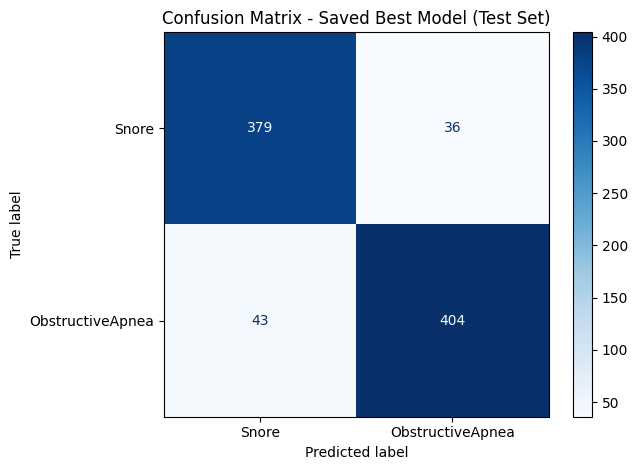

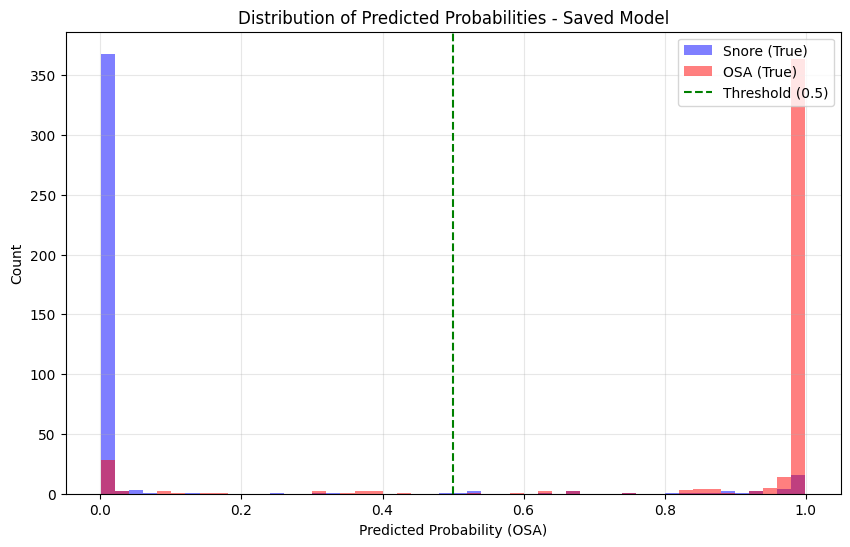


🔍 THRESHOLD ANALYSIS
------------------------------
Threshold 0.3: Accuracy=0.9142, F1=0.9140
Threshold 0.4: Accuracy=0.9084, F1=0.9083
Threshold 0.5: Accuracy=0.9084, F1=0.9083
Threshold 0.6: Accuracy=0.9095, F1=0.9095
Threshold 0.7: Accuracy=0.9084, F1=0.9083


In [44]:
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2Processor
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

print("="*60)
print("EVALUATING SAVED BEST MODEL")
print("="*60)

# Load saved model + processor
saved_model_path = str(SAVE_DIR / "wav2vec2_best")
print(f"Loading model from: {saved_model_path}")

saved_model = Wav2Vec2ForSequenceClassification.from_pretrained(saved_model_path).to(device)
saved_processor = Wav2Vec2Processor.from_pretrained(saved_model_path)
processor = saved_processor  # overwrite processor with saved one
print("✅ Model and processor loaded successfully!")

# --- Evaluation function ---
def evaluate_model(model, dataloader, threshold=VAL_THRESHOLD):
    model.eval()
    all_true, all_pred, all_probs = [], [], []
    running_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_values = batch["input_values"].to(device)
            attn_mask    = batch["attention_mask"].to(device) if batch["attention_mask"] is not None else None
            labels       = batch["labels"].to(device)

            outputs = model(input_values, attention_mask=attn_mask, labels=labels)
            loss, logits = outputs.loss, outputs.logits

            probs = torch.softmax(logits, dim=1)[:, 1]  # prob of OSA
            preds = (probs >= threshold).long()

            running_loss += loss.item()
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / max(1, len(dataloader))
    acc = (np.array(all_true) == np.array(all_pred)).mean()
    f1  = f1_score(all_true, all_pred, average="macro")
    return avg_loss, acc, f1, np.array(all_true), np.array(all_pred), np.array(all_probs)


# --- Run evaluation ---
test_loss, test_acc, test_f1, y_true, y_pred, y_probs = evaluate_model(
    saved_model, test_loader, threshold=VAL_THRESHOLD
)

print("\n📊 SAVED MODEL - TEST SET RESULTS")
print("-" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 (macro): {test_f1:.4f}")

# Class distribution check
print(f"\nUnique classes in true labels: {np.unique(y_true)}")
print(f"Unique classes in predictions: {np.unique(y_pred)}")

# Classification report
class_names = ["Snore", "ObstructiveApnea"]
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, labels=[0,1], target_names=class_names, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Saved Best Model (Test Set)")
plt.tight_layout()
plt.show()

# Probability distribution
plt.figure(figsize=(10, 6))
plt.hist(y_probs[y_true == 0], bins=50, alpha=0.5, label="Snore (True)", color="blue")
plt.hist(y_probs[y_true == 1], bins=50, alpha=0.5, label="OSA (True)", color="red")
plt.axvline(x=VAL_THRESHOLD, color="green", linestyle="--", label=f"Threshold ({VAL_THRESHOLD})")
plt.xlabel("Predicted Probability (OSA)")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities - Saved Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Threshold analysis
print(f"\n🔍 THRESHOLD ANALYSIS")
print("-" * 30)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds_thresh = (y_probs >= thresh).astype(int)
    acc_thresh = (y_true == preds_thresh).mean()
    f1_thresh = f1_score(y_true, preds_thresh, average="macro")
    print(f"Threshold {thresh:.1f}: Accuracy={acc_thresh:.4f}, F1={f1_thresh:.4f}")


In [ ]:
# Save final model
final_model_dir = SAVE_DIR / "wav2vec2_final"
final_model_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(final_model_dir))
processor.save_pretrained(str(final_model_dir))
print(f"\n💾 Final model saved to: {final_model_dir}")

# Save training history
history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_f1s': train_f1s,
    'val_f1s': val_f1s,
    'best_val_f1': best_val_f1,
    'best_epoch': best_epoch,
    'test_f1': test_f1,
    'test_acc': test_acc,
    'threshold': VAL_THRESHOLD
}

with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f"📊 Training history saved to: {SAVE_DIR / 'training_history.json'}")

# Performance summary
print(f"\n{'='*50}")
print("PERFORMANCE SUMMARY")
print(f"{'='*50}")
print(f"📊 Dataset: {len(df_train_all)} training samples (after filtering)")
print(f"🎯 Best Validation F1: {best_val_f1:.4f} at epoch {best_epoch}")
print(f"🏆 Final Test F1: {test_f1:.4f}")
print(f"🎯 Test Accuracy: {test_acc:.4f}")
print(f"⚙️  Threshold used: {VAL_THRESHOLD}")
print(f"💾 Model saved at: {SAVE_DIR}")


💾 Final model saved to: C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V4\wav2vec2_final
📊 Training history saved to: C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V4\training_history.json

PERFORMANCE SUMMARY
📊 Dataset: 924 training samples (after filtering)
🎯 Best Validation F1: 0.9809 at epoch 15
🏆 Final Test F1: 0.8242
🎯 Test Accuracy: 0.8271
⚙️  Threshold used: 0.5
💾 Model saved at: C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V4


In [ ]:
# # Debug: Check what files are actually available in test directory
# print("🔍 DEBUGGING TEST DATA FILES")
# print("="*50)

# # Check test directory contents
# import os
# print(f"Test directory: {TEST_NPY_DIR}")
# print(f"Directory exists: {TEST_NPY_DIR.exists()}")

# if TEST_NPY_DIR.exists():
#     test_files = list(TEST_NPY_DIR.glob("*.npy"))
#     print(f"Total .npy files in test directory: {len(test_files)}")
    
#     # Show first few files
#     print("\nFirst 10 files:")
#     for i, file in enumerate(test_files[:10]):
#         print(f"  {file.name}")
    
#     # Extract patient IDs from available files
#     available_pids = set()
#     for file in test_files:
#         # Try to extract patient ID from filename
#         parts = file.stem.split('-')
#         if len(parts) >= 2:
#             pid_str = parts[0]
#             try:
#                 pid = int(pid_str)
#                 available_pids.add(pid)
#             except:
#                 pass
    
#     print(f"\nAvailable patient IDs in test files: {sorted(available_pids)}")
    
#     # Check what patient IDs are in test CSV
#     test_csv_pids = set(df_test_all['patient_id'].unique())
#     print(f"Patient IDs in test CSV: {sorted(test_csv_pids)}")
    
#     # Find missing patient IDs
#     missing_pids = test_csv_pids - available_pids
#     available_in_csv = test_csv_pids & available_pids
    
#     print(f"\nMissing patient IDs (in CSV but no files): {sorted(missing_pids)}")
#     print(f"Available patient IDs (in both CSV and files): {sorted(available_in_csv)}")
    
#     # Filter test dataset to only include available files
#     print(f"\nOriginal test dataset size: {len(df_test_all)}")
#     df_test_filtered = df_test_all[df_test_all['patient_id'].isin(available_in_csv)].reset_index(drop=True)
#     print(f"Filtered test dataset size: {len(df_test_filtered)}")
    
#     if len(df_test_filtered) > 0:
#         print(f"\nFiltered test data class distribution:")
#         print("0 (Snore):", (df_test_filtered["label"] == 0).sum())
#         print("1 (OSA):", (df_test_filtered["label"] == 1).sum())
        
#         # Create new test dataset and dataloader with filtered data
#         test_ds_filtered = W2V2NpyDataset(df_test_filtered, TEST_NPY_DIR)
#         test_loader_filtered = DataLoader(test_ds_filtered, batch_size=BATCH_SIZE, shuffle=False,
#                                         collate_fn=collate_w2v2, num_workers=0, pin_memory=True)
        
#         print(f"\n✅ Created filtered test dataset with {len(df_test_filtered)} samples")
#         print("You can now use 'test_loader_filtered' for evaluation")
#     else:
#         print("❌ No valid test samples found!")
# else:
#     print("❌ Test directory does not exist!")